In [1]:
from xseas import SeasonDetect, train_perceptron_spatial
from pathlib import Path
import xarray as xr

In [2]:
import yaml

with open('paths.local.yaml', 'r') as file:
    paths = yaml.safe_load(file)

WORKING_FOLDER = Path(paths['WORKING_FOLDER'])
WORKING_FOLDER = Path('/Users/jacopograssi/Documents/XSeas/prova_pro')

In [3]:
# Initialize project
project = SeasonDetect(WORKING_FOLDER, "config.yaml")

✅ Using existing XSeas project at: /Users/jacopograssi/Documents/XSeas/prova_pro


In [4]:
project.prenormalize_ERA5()

✅ ERA5 already prenormalized. Skipping...


In [5]:
project.prenormalize_CMIP6()

✅ ACCESS-CM2 already prenormalized. Skipping...
✅ BCC-CSM2-MR already prenormalized. Skipping...


In [6]:
project_clustering_path = project.clustering_path

if not project_clustering_path.exists():    
    project.perform_clustering()

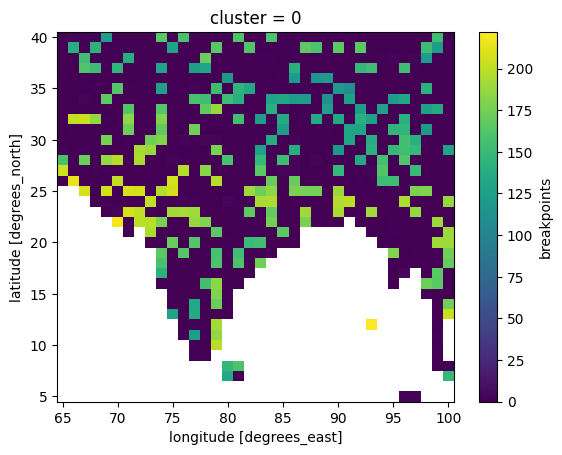

In [7]:
xr.open_dataset(project.clustering_path).breakpoints.sel(cluster=0).plot()

In [8]:
project.train_perceptron_models(epochs=2)

🔄 Training perceptron models...
   Training years: 50
   Epochs: 2
🤖 Avvio training perceptron spaziale...
Training row 1/36
🤖 Avvio training perceptron spaziale...
Training row 1/36


100%|██████████| 36/36 [00:03<00:00,  9.49it/s]


Training row 2/36


100%|██████████| 36/36 [00:00<00:00, 677.57it/s]


Training row 3/36


...

Training row 35/36


100%|██████████| 36/36 [01:01<00:00,  1.70s/it]


Training row 36/36


100%|██████████| 36/36 [00:56<00:00,  1.58s/it]

✅ Training perceptron completato


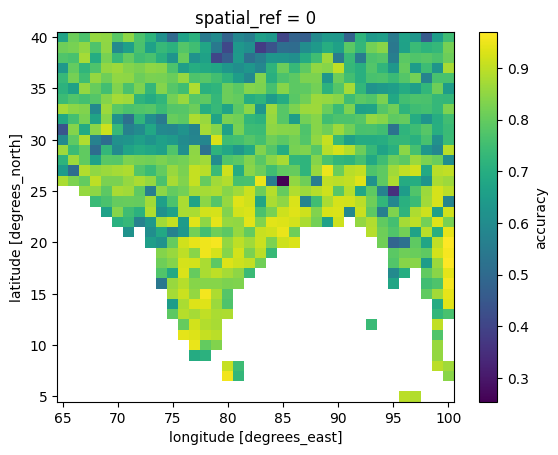

In [11]:
# Visualizza accuracy media dal file delle metriche
import xarray as xr
from pathlib import Path

metrics_file = project.perceptron_path / 'metrics' / 'training_metrics.nc'
if metrics_file.exists():
    mds = xr.open_dataset(metrics_file)
    mds.accuracy.plot()
else:
    print("Metriche non trovate:", metrics_file)